# Module 14: Watershed Delineation


## Learning Objectives

At the end of this module, you should be able to:
- Derive and analyze watershed characteristics from raster elevation data by applying flow direction, flow accumulation, and watershed delineation algorithms using the pysheds library.
- Integrate geospatial data and hydrologic reasoning in a reproducible Python workflow


## Introduction

Watershed analysis is the process of analyzing the landscape and hydrology of watersheds, defined as land areas where surface water drains to a common outlet, such as a river, lake, or ocean. Rainfall that falls across a landscape is routed by topography into channels, streams, and rivers, concentrating runoff in low-lying areas where flooding can occur. Understanding where water flows, how much area contributes to a given location, and why certain regions are more flood-prone requires explicit analysis of watershed structure.

In early July 2025, Central Texas’s Hill Country was struck by catastrophic flash flooding after a mesoscale storm enhanced with tropical moisture dumped extreme rainfall—more than 20 inches in parts of the region—over steep, drought-hardened terrain. Rivers like the Guadalupe surged tens of feet within hours, overwhelming banks and infrastructure. The floods claimed at least 135 lives, with Kerr County hardest hit and many victims at a summer camp along the river. Widespread property destruction, washed-out roads, and inundated communities prompted federal and state disaster declarations, making it one of the deadliest inland flash floods in recent U.S. history.

In this module, we will use the July 2025 Central Texas flood as a motivating example to explore how digital elevation models (DEMs) can be used to delineate watersheds and drainage networks. Texas Hill Country's complex terrain—characterized by steep slopes, flashy tributaries, and rapid urban runoff—provides an ideal setting for examining how topography controls hydrologic response during extreme precipitation events.

In order to perform our analysis, we will need to complete a series of steps including loading the digital elevation data for the study region, defining the areas of the watersheds of interest, analyzing the landscapes in each watershed, and visualizing the results. In the following sections we will explore each of these topics in more detail and demonstrate how to perform watershed analysis using Python.

## Getting started

We can start by importing the libraries we need for this analysis. In this case, we will be using `xarray`, `rioxarray`, `pysheds`, `geopandas`, and `geocube` in addition to more familiar packages such as `matplotlib` and `numpy`. We will also use some custom functions from the `basin_functions.py` file.

In [1]:
from basin_functions import *
from geocube.vector import vectorize
import geopandas as gpd
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from pysheds.grid import Grid
from pysheds.view import Raster, ViewFinder
import rioxarray as rxr
import xarray as xr

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### Loading the digital elevation data
We will use a Digital Elevation Model (DEM) file (**n30_w100_1arc_v3.tif**) downloaded from the U.S. Geological Survey (USGS) National Map Data Download Application. It is a 1 arc-second (~30 m) resolution DEM product, as part of the USGS seamless elevation products derived primarily from SRTM data and refined through subsequent processing (Version 3). The tile name indicates that the file covers a 1° × 1° area from 30°N to 31°N latitude and 100°W to 99°W longitude, spanning a portion of Central Texas / Texas Hill Country.

To start, we can read in the data using `rioxarray`.

In [3]:
dem_file = 'data/n30_w100_1arc_v3.tif'
texas = rxr.open_rasterio(dem_file).drop_vars('band')[0]

Now we can take a look at the data by printing out the xarray `DataArray` called `texas`.

In [4]:
texas

<xarray.DataArray (y: 3601, x: 3601)> Size: 26MB
[12967201 values with dtype=int16]
Coordinates:
  * y            (y) float64 29kB 31.0 31.0 31.0 31.0 ... 30.0 30.0 30.0 30.0
  * x            (x) float64 29kB -100.0 -100.0 -100.0 ... -99.0 -99.0 -99.0
    spatial_ref  int64 8B 0
Attributes: (12/27)
    AREA_OR_POINT:                Point
    DTED_CompilationDate:         2
    DTED_DataEdition:             2
    DTED_DigitizingSystem:        SRTM      
    DTED_HorizontalAccuracy:      13
    DTED_HorizontalDatum:         WGS84
    ...                           ...
    DTED_VerticalAccuracy_UHL:    5
    DTED_VerticalDatum:           E96
    _FillValue:                   -32767
    scale_factor:                 1.0
    add_offset:                   0.0
    units:                        m

As we can see, the dataset has around 13 million points (3601 longitude points by 3601 latitude points). The values at each point are the elevation of the surface or `NaN` if the points are below sea level or missing from the DEM.

To make an elevation map from the DataArray:

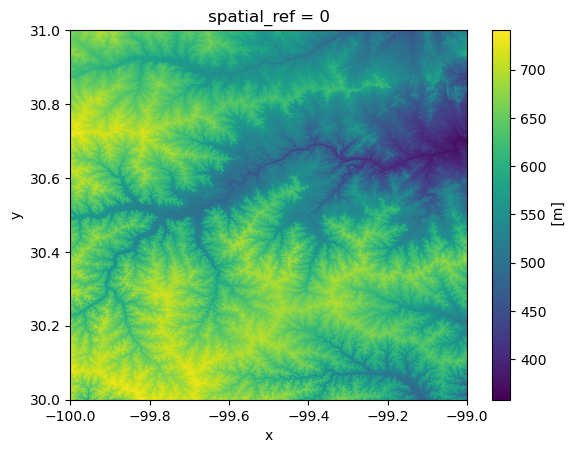

In [5]:
texas.plot()

## Extracting watersheds using pysheds
### Overview of watershed delineation

The process of watershed delineation is essentially defining the points that lie upstream or upslope of a specified outlet point. Outlet points can be found various ways. In this case study, we will use the Kerrville Lake Dam (29.99713N, -99.10659W) as the outlet.

Once outlet points have been selected, there are still several important steps for processing a DEM such that watersheds can be defined. For instance, the DEM must be updated such that a route to the outlet points can be found using the assumption that water will flow to neighboring cells at lower elevations. The first set of steps are collectively referred to as "hydrological conditioning" of the DEM. 

Conditioning steps include:

- Filling pits in the DEM. Pits are individual cells in the DEM that have no neighbor cell with a lower elevation. The elevations of pits must be increased to the point that their height is equal to or greater than at least one neighbor cell.
- Filling depressions in the DEM. Similar to filling pits, groups of cells that have no outlet (depressions) must be filled (by increasing their elevation) such that the elevation is equal to or greater than at least one neighbor cell.
- Resolving flats. Water cannot flow downhill in flat regions, such as a lake. Thus, flat regions in the DEM also need to be corrected such that water can always flow to a downstream outlet.

Once the DEM has been conditioned, there are a few additional steps needed to produce the necessary information for watershed delineation. These steps include:

- Determining flow directions. In order to be able to define the watershed it is necessary to identify all DEM cells where water would be routed to the defined watershed outlet. Flow directions indicate the direction in which water would be expected to flow from every cell, which allows the directions to be traced upstream from the outlet to the point where flow directions diverge at the boundary of the watershed.
- Determining flow accumulation. Flow accumulation is a calculation of how many upstream cells drain into each cell in the DEM. This isn't strictly needed for watershed delineation, but can be helpful in finding river channels in the DEM if selected outlet points are not located exactly in a channel cell.

Once these steps have been completed, it is possible to delineate a watershed upstream of a specified outlet point.

In [6]:
texas.rio.crs

CRS.from_epsg(4326)

### Reading the DEM into pysheds

At this stage we can begin the DEM processing steps using `pysheds`. `pysheds` is a Python library designed for [efficient processing of DEM data and extraction of watersheds](https://mattbartos.com/pysheds/). 

The first step is to read in the DEM. To do this, we need to define the elevation data that will be used (`data`), the affine transformation matrix (`affine`), the coordinate reference system (`crs`), and the value used to indicate missing data (`nodata`). As a reminder, 
- The ***transform*** describes how pixel coordinates (row, column) map to real-world coordinates (e.g., meters or degrees). It defines the raster’s scale, rotation, and location.
- The ***affine*** transformation is a mathematical model commonly used in Python to define the spatial transformation of raster data. It consists of six parameters that control translation (position), scaling (resolution), and rotation/skew. 

In [7]:
data = texas.data
affine = texas.rio.transform()
crs = texas.rio.crs

# keep same data type as DEM values for nodata
nodata = data.dtype.type(-9999)

The values above can then be used to define the pysheds `ViewFinder`, which defines the spatial reference system for the DEM. After defining the `ViewFinder`, the elevation data can be read in using the pysheds `Raster()` function.

In [8]:
viewfinder = ViewFinder(affine=affine, shape=data.shape, crs=crs, nodata=nodata)
dem = Raster(data, viewfinder=viewfinder)

Finally, a pysheds `Grid` object is created, which allows visualization of the DEM data and the use of various `Grid` methods for processing the elevation data.

In [9]:
# Create grid
grid = Grid.from_raster(dem)

### Preparing a DEM for analysis in pysheds

Now we are ready to begin processing the data. The first step in the process is to detect any pits in the DEM, which can be done using the `.detect_pits()` `Grid` method.

In [10]:
# Detect number of pits in DEM
pits = grid.detect_pits(dem)
npits = np.count_nonzero(pits)

# Check number of pits
print(f"Number of pits found: {npits}")

Number of pits found: 51909


After detecting the pits it is possible to visualize their locations by plotting the `pits` values, as shown below.

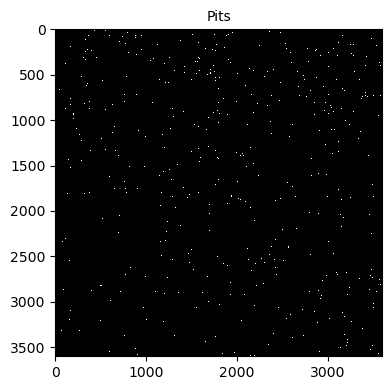

In [11]:
# Plot pits if more than zero
if npits > 0:
    # Plot pits
    fig, ax = plt.subplots(figsize=(6, 4))
    fig.patch.set_alpha(0)

    plt.imshow(pits, cmap="Greys_r", vmin=0, vmax=1, interpolation='nearest', zorder=1)
    plt.title("Pits", size=10)
    plt.tight_layout()

As there are clearly many pits in the DEM, it is necessary to fill in the pits using the `.fill_pits()` method. After doing this, we can check that the pits have been filled using an `assert` statement.

In [12]:
# Fill pits and check they have been filled
pit_filled_dem = grid.fill_pits(dem)
pits = grid.detect_pits(pit_filled_dem)
assert not pits.any()

So, now all pits have been filled, but other depressions may still exist in the DEM, which we will now detect (and fill if they exist). We can detect depressions using the `detect_depressions()` method.

In [13]:
# Detect depressions - Slow. May take 5 minutes or more.
depressions = grid.detect_depressions(pit_filled_dem)

If we were to check the number of depressions like was done for the pits above, we would find there are zero depressions. However, this is incorrect, and may be related to the large number of nodata values in the sea areas of the DEM. There are indeed some depressions that need to be filled, and we can do that below.

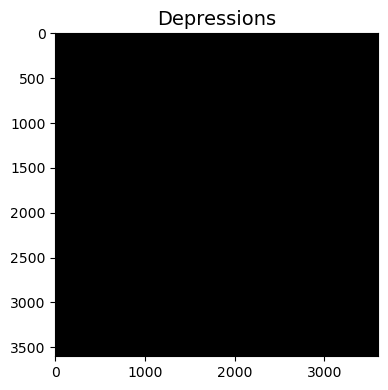

In [14]:
# Plot depressions
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_alpha(0)

plt.imshow(depressions, cmap="Greys_r", vmin=0, vmax=1, interpolation='nearest', zorder=1)
plt.title("Depressions", size=14)
plt.tight_layout()

The next step is to fill depressions. Depressions can be filled using the `.fill_depressions()` method. As above, we can use an `assert` statement to ensure there are not remaining depressions in the DEM.

In [15]:
# Fill depressions - Slow
flooded_dem = grid.fill_depressions(pit_filled_dem)
depressions = grid.detect_depressions(flooded_dem)
assert not depressions.any()

Now that all depressions and pits in the DEM have been filled, we can proceed to handling flow routing across flats (such as lakes) in the DEM. We will first detect if there are any flats using the `.detect_flats()` method.

In [16]:
# Detect flats
flats = grid.detect_flats(flooded_dem)
nflats = np.count_nonzero(flats)

# Check number of flats
print(f"Number of flats found: {nflats}")

Number of flats found: 1949584


As was the case earlier, it is possible to visualize the locations of flat regions in the DEM by plotting the `flats` values. In contrast to the case for the pits and depressions above, visualizing the flat regions in the DEM clearly shows their locations.

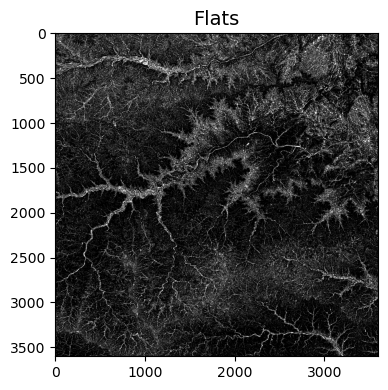

In [17]:
# Plot flats
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_alpha(0)

plt.imshow(flats, cmap="Greys_r", zorder=1)
plt.title("Flats", size=14)
plt.tight_layout()

Flat regions in the DEM can be handled by processing the flooded DEM to determine how water would be routed across the flat regions. In `pysheds`, this can be done using the `.resolve_flats()` method.

In [18]:
# Resolve flats
inflated_dem = grid.resolve_flats(flooded_dem)

Now that we have resolved the flat regions, we can move on to the steps on determining flow directions and flow accumulation.

### Calculating values related to surface water flows

At this stage we can use the inflated DEM (with flats resolved) to determine two key things: (1) the direction water flows at all points on the surface of the DEM (flow direction), and (2) the number of cells draining into each cell in the DEM (flow accumulation). Flow directions can be calculated using the `.flowdir()` method and flow accumulation can be calculated using the `.accumulation()` method, as shown below.

In [19]:
# Compute flow direction based on corrected DEM (D8)
fdir = grid.flowdir(inflated_dem)

# Compute flow accumulation based on computed flow direction
acc = grid.accumulation(fdir)

In [20]:
acc.max()

Raster(7715560.)

As was the case earlier, we can again check the values for the flow directions and flow accumulation by creating a plot of them. Here, we can plot the flow accumulation (`acc`) to see how things look.

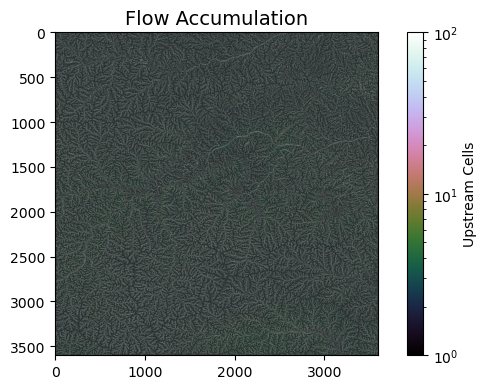

In [21]:
# Plot flow accumulation, if requested
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_alpha(0)
im = ax.imshow(
    acc,
    zorder=2,
    cmap="cubehelix",
    norm=colors.LogNorm( 1, 1e2 ),
    interpolation="bilinear",
)
plt.colorbar(im, ax=ax, label="Upstream Cells")
plt.title("Flow Accumulation", size=14)
plt.tight_layout()

### Defining and extracting a watershed

With the flow directions and accumulation calculated, we can proceed to the steps for extracting a watershed that can be further analyzed. Note that within this section the terms "watershed" and "catchment" will be used interchangeably, as some of the tools in `pysheds` use the term "catchment."

In order to get started, we need to select the Kerrville Lake Dam (29.99713N, -99.10659W) outlet and specify its location.

In [23]:
outlet = (-99.10659, 29.99713)

Once the `outlet` location is defined we can use the `.catchment()` function to define the area of the watershed/catchment. However, we will take one additional step here. Sometimes the location of the outlet coordinates does not fall directly within the channel location in the DEM, which can lead to defining smaller parts of the watershed (e.g., tributary streams) instead of the full desired watershed area. To help with this, `pysheds` has a `.snap_to_mask()` function that will adjust the specified `outlet` point to the nearest cell with a "high" flow accumulation (at least 1000 in this case). This will ensure that the point specified as `outlet` captures the full upstream drainage area.

In [24]:
# Snap outlet point to nearby cell with high flow accumulation
x_snap, y_snap = grid.snap_to_mask(acc > 1000, outlet)

# Delineate the watershed
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, xytype="coordinate")

Now that we have extracted the watershed we can visualize and inspect the results. For the sake of demonstration we will look at four subplots of watershed data produced from the cell below: (1) the watershed extent, (2) the watershed elevations, (3) the watershed flow directions, and (4) the watershed flow accumulation.

In [ ]:
# Clip and set view extents
grid.clip_to(catch)
catch_view = grid.view(catch, nodata=np.nan)
fdir_view = grid.view(fdir, nodata=np.nan)
acc_view = grid.view(acc, nodata=np.nan)
dem_view = grid.view(dem, nodata=np.nan)

# Create figure and plot axes
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
fig.patch.set_alpha(0)

# Plot watershed extent
im = axes[0, 0].imshow(catch_view, extent=grid.extent, zorder=1, cmap="Greys_r")
axes[0, 0].set_title("Extent")
axes[0, 0].set_ylabel("Latitude (°N)")

# Plot watershed elevations
im = axes[0, 1].imshow(dem_view, extent=grid.extent, zorder=1, cmap="viridis")
axes[0, 1].set_title("Elevation")

# Plot watershed flow directions
im = axes[1, 0].imshow(fdir_view, extent=grid.extent, zorder=1, cmap="viridis")
axes[1, 0].set_title("Flow direction")
axes[1, 0].set_xlabel("Longitude (°E)")
axes[1, 0].set_ylabel("Latitude (°N)")

# Plot watershed flow accumulation
im = axes[1, 1].imshow(
    acc_view,
    extent=grid.extent,
    zorder=2,
    cmap="cubehelix",
    norm=colors.LogNorm(1, acc.max()),
    interpolation="bilinear",
)
axes[1, 1].set_title("Flow accumulation")
axes[1, 1].set_xlabel("Longitude (°E)")

# Add a figure title
plt.suptitle("Kerrville Lake Dam watershed")
plt.tight_layout()

## Analyzing the watershed data
### Cell Distance to Pour Point
Having extracted the watershed area, there are a handful of additional analyses we can perform using `pysheds`. A good place to start is by calculating the distance from each point in the watershed to the defined outlet point. This provides a measure of how many cells water must flow across to reach the outlet, which can be converted to a distance in meters. We can use the `pysheds` `.distance_to_outlet()` function for this calculation.

In [26]:
# Compute distance to outlet
dist = grid.distance_to_outlet(
    x=x_snap,
    y=y_snap,
    fdir=fdir,
    xytype="coordinate",
)

Similar to the plot above of the catchment data, we can plot the distance to the outlet using `.imshow()`.

Text(0.5, 1.0, 'Distance to outlet')

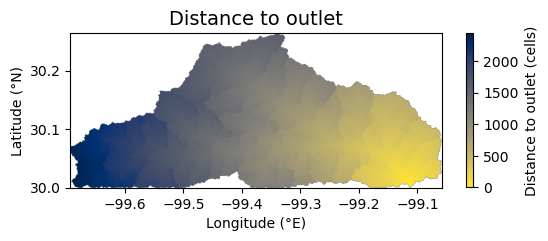

In [38]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_alpha(0)

# Plot distance to outlet
im = ax.imshow(dist, extent=grid.extent, zorder=2, cmap="cividis_r")

# Add colorbar, axis labels, and a title
plt.colorbar(im, ax=ax, label="Distance to outlet (cells)", shrink=0.5)
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Distance to outlet", size=14)

### Extract River Network
It is also possible to extract the network of channels in the watershed using the `.extract_river_network()` function. This will identify all regions of the flow accumulation grid where the accumulation exceeds a given threshold (parameter `acc`). In our case, all regions with an accumulation of over 100 cells will be identified. In addition, the channel segments are plotted using different colors to indicate when there are channel segments than join (channel junctions).

In [28]:
# Extract river network
branches = grid.extract_river_network(fdir, acc > 100)

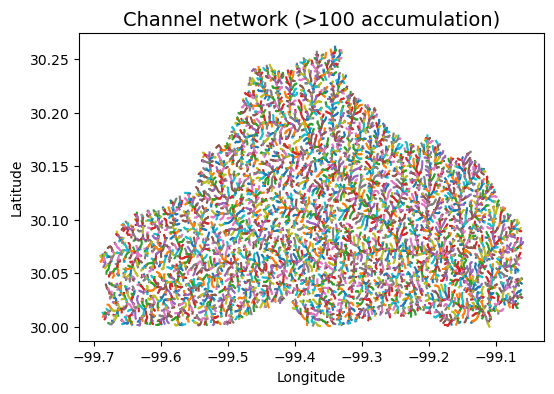

In [ ]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 4))

# Plot channel segments
for branch in branches["features"]:
    line = np.asarray(branch["geometry"]["coordinates"])
    plt.plot(line[:, 0], line[:, 1])

# Add axis labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Channel network (>100 accumulation)", size=14)

### Exporting the watershed data to xarray

While it is also possible to perform other watershed analyses using `pysheds` (check the [`pysheds` documentation](https://mattbartos.com/pysheds/) for more examples), the next set of analyses relies on exporting our watershed elevation data from `pysheds` to `xarray`. Exporting to `xarray` will allow us to easily interact with the elevation data for the watershed, including performing analyses of the watershed elevations such as calculating the watershed hypsometry and hypsometric integral. 

In order to export the watershed elevations to `xarray` we need to extract the elevations themselves, as well as the latitude and longitude values for the watershed. Once those values have been extracted, an `xarray` `DataArray` can be created using the `DataArray` function, as shown below.

In [30]:
# Convert watershed data for xarray
catchment = dem_view
data = catchment.data

# Get latitude and longitude ranges
lat = np.unique(catchment.coords[:, 0])
# Get latitude points in correct order (reverse order of array values)
lat = np.flip(lat)
lon = np.unique(catchment.coords[:, 1])

# Create DataArray
catch_xr = xr.DataArray(catchment.base, coords={"y": lat, "x": lon}, dims=["y", "x"])


We can confirm that the conversion has gone as expected by plotting the watershed data using the `xarray` `.plot()` function.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

catch_xr.plot(ax=ax, cmap="plasma", cbar_kwargs={"label": "Elevation (m)"})
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Kerrville Lake Dam watershed in xarray")

### Calculating basin hypsometry

Our next step is to calculate a hypsometric integral for the basin, which can provide an estimate of the volume of material in the watershed that has been eroded by rivers and glaciers. `Hypsometry` (or hypsometric analysis) refers to the measurement of the distribution of elevations of Earth's surface elevations within a given area. In essence, it is a means to explore how much land area is within different elevation ranges, similar to calculating a histogram of elevations. On Earth, we can observe that [the majority of land area is at elevations within 800 meters of sea level, while little land area is at elevations greater than three kilometers](https://en.wikipedia.org/wiki/Hypsometry). Hypsometric analysis of watersheds refers to the measurement of the distribution of elevations within a watershed (or drainage basin). A common product of hypsometric analysis of a watershed is a `hypsometric curve`, which shows the distribution of watershed area above a given elevation in the watershed (i.e., a cumulative distribution). The elevation range and areas of hypsometric curves are often normalized to allow comparison between various watersheds, as shown in the example below.

<img src="img/hypsometric-curve.png" width="600">

Why do we care about the hypsometry of a watershed? There are a few reasons. First, the distribution of elevations in a drainage basin can tell something about the geological processes that shaped the land surface in the drainage basin. Rivers and glaciers carve their valleys into the underlying soil/rock, eroding the landscape and altering the distribution of elevations within the basin. However, valley glaciers tend to form broad, deep valleys and remove more mass from a watershed than rivers would, which would often be reflected in the hypsometry of the watershed. The `hypsometric integral` is a single value that can be calculated by integrating the normalized hypsometric curve. Glaciated watersheds often experience more erosion of rock than fluvial watersheds, and the decreased volume of rock is reflected in watershed areas concentrated at lower elevations and a lower hypsometric integral.

`hypsometric integral` range from 0 to 1:
- High HI (> ~0.6) → youthful, steep, little erosion
- Low HI (< ~0.35) → old, subdued, heavily eroded
- Mid-range (~0.35–0.6) → mature/transitional

Calculating the basin hypsometry involves determining the frequency distribution of elevation within a given watershed. In other words, we want to know how frequent (in terms of the number of DEM cells) elevations occur within given elevation ranges, such as 600–800 m above sea level. We can calculate a histogram of elevations for the watershed using the `numpy.histogram()` function, e.g., with 50 bins. Note: we exclude NoData values from the dataset using the `~np.isnan(catch_xr.values)` mask.

In [32]:
catchment_elevations = catch_xr.values[~np.isnan(catch_xr.values)]
nbins = 50
counts, bins = np.histogram(catchment_elevations, bins=nbins)


The resulting histogram can be plotted. However, plotting the output from histograms calculated using `numpy` is a bit clumsy with `matplotlib`, so we can instead use the `matplotlib` `pyplot.hist()` function to quickly show the elevation histogram.

In [ ]:
# Create figure and axis
fig, ax = plt.subplots(1, 1)

# Plot elevation histogram
ax.hist(catchment_elevations, bins=nbins)

# Add axis labels
ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Number of occurrences")
plt.tight_layout()

The hypsometry of the watershed relies on finding the proportion of elevations above a given point from the lowest elevation to the highest in the basin. We can do this in several steps. First, a cumulative sum of the histogram elevation distribution should be calculated. In addition, the cumulative distribution should be reversed such that the elevation fraction is 1.0 (or 100%) above the minimum elevation and 0.0 (or 0%) above the maximum. Finally, the elevation distribution and ranges should be normalized to one, as this will make it easier to compare distributions for different watersheds.

In [34]:
# Calculate (normalized) cumulative distribution
norm_counts = counts.cumsum() / counts.cumsum().max()

# Convert to area above min elevation
norm_counts = 1 - norm_counts

# Normalize elevation ranges
norm_bins = (bins - bins.min()) / (bins.max() - bins.min())

At this point we can use the normalized elevation distribution and ranges to calculate the hypsometric integral for the watershed and create a plot of the hypsometric curve. Because the elevations and areas have been normalized already, we can simply sum the product of the occurrences of each area multiplied by the width of the normalized bins.

In [35]:
# Calculate hypsometric integral
bin_width = norm_bins[1] - norm_bins[0]
hyps_integral = sum(norm_counts * bin_width)
print(f"Hypsometric integral: {abs(hyps_integral):.3f}")

Hypsometric integral: 0.559


Because the hypsometric integral value is higher than 0.5, slightly less than half of the volume of rock has been removed by erosion.
An HI of 0.559 suggests a well-developed, actively evolving watershed—not overly steep or raw, but not yet geomorphically "worn down."

To help visualize this result we can plot the hypsometric curve along with a linear reference line for a hypsometric integral of 0.5, as shown below.

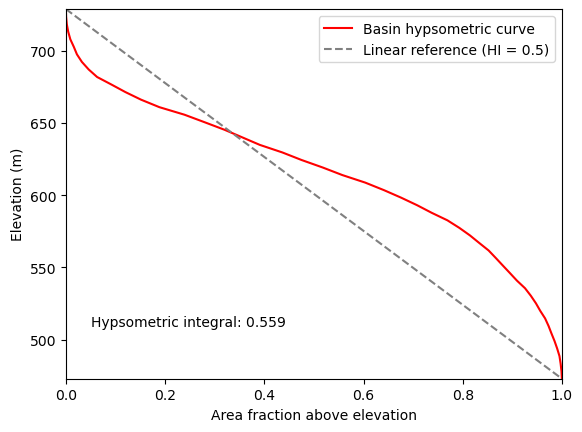

In [36]:
fig, ax = plt.subplots(1, 1)
# ax.plot(bins[:-1], counts, "k+")
ax.plot(norm_counts, bins[:-1], "r", label="Basin hypsometric curve")
ax.set_xlabel("Area fraction above elevation")
ax.set_ylabel("Elevation (m)")
ax.plot(
    [0.0, 1.0],
    [bins[:-1].max(), bins[:-1].min()],
    "--",
    color="gray",
    label="Linear reference (HI = 0.5)",
)
ax.legend()
ax.set_xlim(0.0, 1.0)
ax.set_ylim(bins[:-1].min(), bins[:-1].max())
ax.text(
    0.05,
    (0.05 * bins[:-1].max()) + bins[:-1].min(),
    f"Hypsometric integral: {abs(hyps_integral):.3f}",
);